In [1]:
import yasa
edf_path = yasa.fetch_sample("night_young.edf")
hypno_path = yasa.fetch_sample("night_young_hypno.csv")

In [2]:
import mne
raw = mne.io.read_raw_edf(edf_path, preload=True)
raw

Extracting EDF parameters from /Users/raphael.vallat/Library/Caches/yasa/night_young.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 5783999  =      0.000 ... 28919.995 secs...


<RawEDF | night_young.edf, 23 x 5784000 (28920.0 s), ~1015.0 MiB, data loaded>

In [3]:
print(raw.ch_names)

['ROC-A1', 'LOC-A2', 'C3-A2', 'O2-A1', 'C4-A1', 'O1-A2', 'EMG1-EMG2', 'Fp1-A2', 'Fp2-A1', 'F7-A2', 'F3-A2', 'FZ-A2', 'F4-A1', 'F8-A1', 'T3-A2', 'CZ-A2', 'T4-A1', 'T5-A2', 'P3-A2', 'PZ-A2', 'P4-A1', 'T6-A1', 'EKG-R-EKG-L']


In [4]:
raw.drop_channels(["ROC-A1", "LOC-A2", "EMG1-EMG2", "EKG-R-EKG-L"])
chan = raw.ch_names
print(chan)

['C3-A2', 'O2-A1', 'C4-A1', 'O1-A2', 'Fp1-A2', 'Fp2-A1', 'F7-A2', 'F3-A2', 'FZ-A2', 'F4-A1', 'F8-A1', 'T3-A2', 'CZ-A2', 'T4-A1', 'T5-A2', 'P3-A2', 'PZ-A2', 'P4-A1', 'T6-A1']


In [5]:
raw.resample(100)
sf = raw.info["sfreq"]
sf

100.0

In [6]:
raw.filter(0.3, 45)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 47.50 Hz)
- Filter length: 1101 samples (11.010 s)



<RawEDF | night_young.edf, 19 x 2892000 (28920.0 s), ~419.2 MiB, data loaded>

In [7]:
data = raw.get_data(units="uV")
print(data.shape)

(19, 2892000)


In [8]:
import pandas as pd
import yasa
hypno = pd.read_csv(hypno_path).squeeze().to_numpy()
hyp = yasa.Hypnogram.from_integers(hypno, freq="30s", scorer="Expert")
hyp

<Hypnogram | 964 epochs x 30s (482.00 minutes), 5 unique stages, scored by Expert>
 - Use `.hypno` to get the string values as a pandas.Series
 - Use `.as_int()` to get the integer values as a pandas.Series
 - Use `.plot_hypnogram()` to plot the hypnogram
See the online documentation for more details.

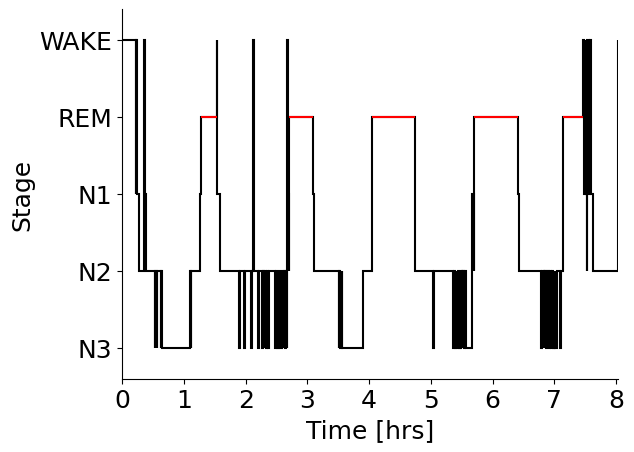

In [9]:
hyp.plot_hypnogram();

In [10]:
hyp.sleep_statistics()

{'TIB': 482.0,
 'SPT': 468.5,
 'WASO': 9.0,
 'TST': 459.5,
 'SE': 95.332,
 'SME': 98.079,
 'SFI': 0.6529,
 'SOL': 13.0,
 'SOL_5min': 14.5,
 'Lat_REM': 77.0,
 'WAKE': 22.5,
 'N1': 17.5,
 'N2': 214.0,
 'N3': 85.5,
 'REM': 142.5,
 '%N1': 3.8085,
 '%N2': 46.5724,
 '%N3': 18.6072,
 '%REM': 31.012}

In [11]:
counts, probs = hyp.transition_matrix()
probs.round(3)

To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,0.773,0.205,0.023,0.000,0.000
N1,0.086,0.629,0.257,0.000,0.029
N2,0.009,0.002,0.876,0.103,0.009
N3,0.006,0.006,0.246,0.743,0.000
REM,0.007,0.007,0.004,0.000,0.982


In [12]:
import numpy as np
np.diag(probs.loc["N2":, "N2":]).mean().round(3)

0.867

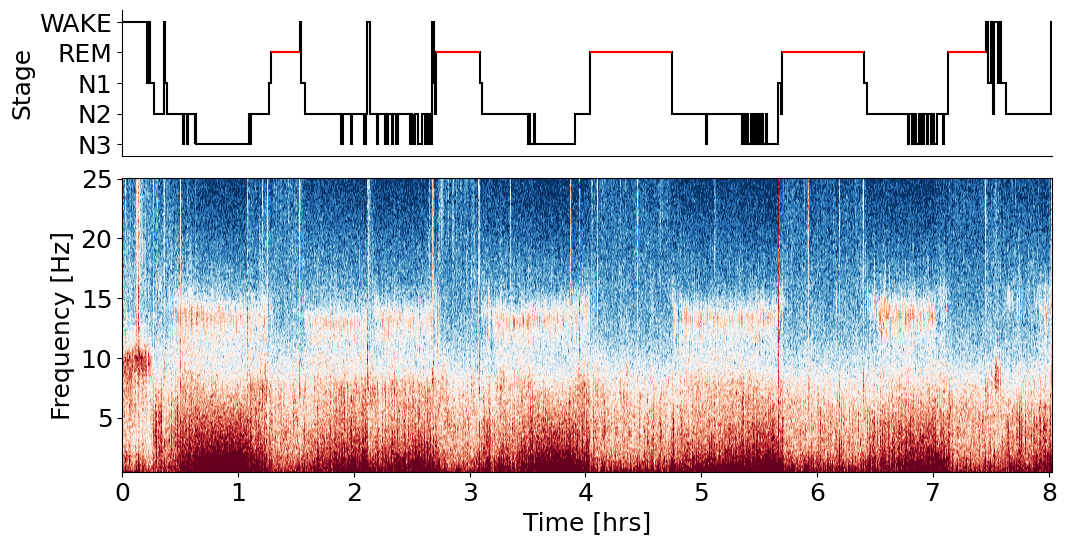

In [13]:
yasa.plot_spectrogram(data[chan.index("C4-A1")], sf, hyp);

In [14]:
yasa.bandpower(raw)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
C3-A2,0.739658,0.176239,0.047144,0.021317,0.013231,0.002413,123.428002,0.25,True
O2-A1,0.715889,0.185061,0.058568,0.025829,0.013081,0.001572,129.104822,0.25,True
C4-A1,0.742428,0.178749,0.044467,0.020102,0.012300,0.001954,144.129054,0.25,True
O1-A2,0.716377,0.188104,0.055707,0.024907,0.013153,0.001752,99.277561,0.25,True
Fp1-A2,0.828335,0.118760,0.030653,0.011095,0.009367,0.001792,162.937314,0.25,True
Fp2-A1,0.822891,0.123286,0.030834,0.011346,0.009967,0.001675,168.516844,0.25,True
F7-A2,0.794740,0.139952,0.037146,0.014804,0.011442,0.001916,111.894873,0.25,True
F3-A2,0.770240,0.158311,0.041458,0.015771,0.011909,0.002312,152.175138,0.25,True
FZ-A2,0.770151,0.163893,0.039909,0.014074,0.009971,0.002001,189.026577,0.25,True


In [15]:
yasa.bandpower(raw, relative=False, bands=[(1, 9, "Slow"), (9, 30, "Fast")])

,Slow,Fast,TotalAbsPow,FreqRes,Relative
Chan,,,,,
C3-A2,79.361806,7.653446,87.015252,0.25,False
O2-A1,84.379108,9.370239,93.749347,0.25,False
C4-A1,94.211885,8.457775,102.669660,0.25,False
O1-A2,65.863712,6.981278,72.844990,0.25,False
Fp1-A2,93.262143,6.333485,99.595628,0.25,False
Fp2-A1,98.157068,6.754739,104.911807,0.25,False
F7-A2,65.786313,5.407878,71.194191,0.25,False
F3-A2,94.863903,7.957011,102.820914,0.25,False
FZ-A2,120.902045,9.080101,129.982146,0.25,False


In [16]:
bandpower = yasa.bandpower(raw, hypno=hyp, include=["N2", "N3", "REM"])
bandpower

Delta     Theta     Alpha     Sigma      Beta     Gamma  \
Stage Chan                                                                 
2     C3-A2   0.740786  0.171013  0.046537  0.028036  0.011639  0.001989   
      O2-A1   0.708989  0.194387  0.052392  0.031345  0.011533  0.001354   
      C4-A1   0.751315  0.168514  0.043238  0.025196  0.010229  0.001508   
      O1-A2   0.708792  0.197322  0.050092  0.030520  0.011768  0.001506   
      Fp1-A2  0.829790  0.115205  0.032085  0.012891  0.008505  0.001523   
      Fp2-A1  0.833446  0.112946  0.031146  0.012843  0.008336  0.001284   
      F7-A2   0.786040  0.144098  0.039380  0.018025  0.010795  0.001663   
      F3-A2   0.783830  0.144356  0.041407  0.018717  0.009925  0.001765   
      FZ-A2   0.797711  0.139201  0.037725  0.016190  0.007724  0.001449   
      F4-A1   0.794755  0.139572  0.037740  0.017500  0.008996  0.001437   
      F8-A1   0.804844  0.131343  0.035031  0.016880  0.010375  0.001527   
      T3-A2   0.718376  0.184052  0.053041  0.028511  0.013970  0.002050   
      CZ-A2   0.757989  0.166225  0.041400  0.023491  0.009315  0.001580   
      T4-A1   0.752828  0.165760  0.043567  0.023738  0.012496  0.001611   
      T5-A2   0.687434  0.202884  0.059285  0.034974  0.013643  0.001780   
      P3-A2   0.723712  0.180087  0.050445  0.033698  0.010516  0.001541   
      PZ-A2   0.740546  0.173798  0.044804  0.030455  0.009000  0.001398   
      P4-A1   0.726899  0.179885  0.048800  0.032196  0.010784  0.001436   
      T6-A1   0.697969  0.198252  0.054814  0.033288  0.014040  0.001637   
3     C3-A2   0.892350  0.077577  0.014799  0.011644  0.003130  0.000500   
      O2-A1   0.853890  0.109016  0.018085  0.014493  0.004059  0.000456   
      C4-A1   0.882569  0.085333  0.015718  0.012637  0.003314  0.000430   
      O1-A2   0.856313  0.108564  0.017348  0.013524  0.003752  0.000499   
      Fp1-A2  0.925755  0.056756  0.010566  0.004424  0.002135  0.000363   
      Fp2-A1  0.923590  0.058310  0.010484  0.004755  0.002502  0.000358   
      F7-A2   0.913269  0.065038  0.012207  0.006284  0.002785  0.000416   
      F3-A2   0.902749  0.071967  0.014442  0.007769  0.002633  0.000439   
      FZ-A2   0.906652  0.070458  0.013381  0.007066  0.002074  0.000369   
      F4-A1   0.904122  0.071885  0.013412  0.007662  0.002555  0.000363   
      F8-A1   0.908001  0.069256  0.012330  0.006874  0.003136  0.000404   
      T3-A2   0.885549  0.084180  0.015885  0.010088  0.003764  0.000533   
      CZ-A2   0.889754  0.080679  0.014823  0.011579  0.002736  0.000430   
      T4-A1   0.879752  0.088976  0.015881  0.010662  0.004247  0.000483   
      T5-A2   0.859902  0.101731  0.019105  0.014526  0.004184  0.000551   
      P3-A2   0.881787  0.085305  0.015174  0.014342  0.002967  0.000425   
      PZ-A2   0.892627  0.077806  0.013430  0.013298  0.002470  0.000369   
      P4-A1   0.876434  0.088668  0.015884  0.015114  0.003476  0.000424   
      T6-A1   0.849769  0.109592  0.019342  0.015592  0.005143  0.000562   
4     C3-A2   0.680684  0.216521  0.057321  0.018154  0.022467  0.004854   
      O2-A1   0.681215  0.185354  0.086681  0.023776  0.020359  0.002615   
      C4-A1   0.680772  0.222914  0.053389  0.016875  0.021793  0.004257   
      O1-A2   0.677618  0.194313  0.080666  0.023636  0.020841  0.002926   
      Fp1-A2  0.772396  0.156401  0.037078  0.012151  0.018062  0.003912   
      Fp2-A1  0.760129  0.167270  0.037326  0.012302  0.019068  0.003906   
      F7-A2   0.752157  0.166552  0.043461  0.014632  0.019337  0.003860   
      F3-A2   0.691142  0.213338  0.049419  0.015688  0.024523  0.005889   
      FZ-A2   0.669307  0.239357  0.049785  0.014047  0.022230  0.005274   
      F4-A1   0.704021  0.206346  0.045551  0.014781  0.024111  0.005189   
      F8-A1   0.768913  0.154885  0.038230  0.013845  0.020302  0.003826   
      T3-A2   0.686211  0.201435  0.063522  0.020844  0.023693  0.004295   
      CZ-A2   0.668357  0.238455  0.052886  0.015303  0.020579  0

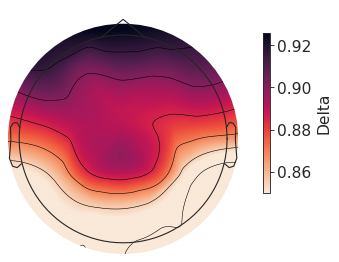

In [17]:
fig = yasa.topoplot(bandpower.xs(3)["Delta"])

In [18]:
sp = yasa.spindles_detect(raw, hypno=hyp, include=("N2", "N3"), verbose="warning")

In [19]:
sp.summary()

,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,1421.19,1421.48,1421.81,0.62,44.199621,24.442528,9.708537,1.787729,0.291183,12.449296,7.0,0.460317,2,C3-A2,0
1,1527.40,1527.56,1527.92,0.52,39.113277,14.701096,8.020877,1.711385,0.325477,13.639412,5.0,0.301887,2,C3-A2,0
2,1530.23,1530.95,1530.99,0.76,42.290339,18.249699,10.362718,1.842073,0.265396,12.729828,10.0,0.935065,2,C3-A2,0
3,1535.13,1535.46,1536.32,1.19,52.396018,27.115593,10.033315,1.925131,0.474792,13.730957,15.0,0.275000,2,C3-A2,0
4,1549.61,1550.08,1550.55,0.94,40.892789,28.063349,10.036494,2.110397,0.523719,13.347028,13.0,0.494737,2,C3-A2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6242,28695.91,28696.33,28696.62,0.71,35.104525,16.267437,8.720188,1.682306,0.248713,13.753436,8.0,0.583333,2,T6-A1,18
6243,28707.86,28708.18,28708.38,0.52,39.108004,19.182367,8.451774,1.794338,0.291040,13.866741,7.0,0.603774,2,T6-A1,18
6244,28717.82,28718.16,28719.29,1.47,41.165725,19.730481,8.606583,1.498107,0.249738,12.879840,18.0,0.229730,2,T6-A1,18
6245,28720.66,28721.00,28721.64,0.98,38.409060,23.599382,9.523745,1.881278,0.321622,13.419676,12.0,0.343434,2,T6-A1,18


In [20]:
sp.summary(grp_chan=True, grp_stage=True)

Count   Density  Duration  Amplitude  AmpFiltered        RMS  \
Stage Channel                                                                 
2     C3-A2      368  1.719626  0.791087  46.486313    26.410342  10.315285   
      C4-A1      313  1.462617  0.792300  51.202672    28.906615  11.466790   
      CZ-A2      323  1.509346  0.810929  59.995110    34.141889  13.392674   
      F3-A2      210  0.981308  0.795476  50.114055    28.355929  11.346969   
      F4-A1      266  1.242991  0.813195  54.295068    30.418649  12.228071   
      F7-A2       90  0.420561  0.718667  35.318405    19.922097   7.952189   
      F8-A1      147  0.686916  0.779320  39.077849    21.554998   8.781296   
      FZ-A2      210  0.981308  0.784381  56.600556    32.325899  12.831021   
      Fp1-A2      49  0.228972  0.739796  41.472701    23.028608   9.300618   
      Fp2-A1     134  0.626168  0.770373  45.714719    25.666941  10.451173   
      O1-A2      412  1.925234  0.808956  43.692037    24.507574   9.711648   
      O2-A1      379  1.771028  0.824116  49.525075    27.378870  11.019275   
      P3-A2      649  3.032710  0.851310  52.774575    30.225705  11.719774   
      P4-A1      518  2.420561  0.834440  53.128355    30.340492  11.833840   
      PZ-A2      628  2.934579  0.855398  57.537985    33.240804  12.808476   
      T3-A2      193  0.901869  0.738653  36.669919    20.819002   8.156961   
      T4-A1      135  0.630841  0.753926  37.297830    20.927276   8.358529   
      T5-A2      433  2.023364  0.789400  42.287889    23.458403   9.384972   
      T6-A1      298  1.392523  0.785101  39.955744    21.869859   8.786098   
3     C3-A2       30  0.350877  0.677333  51.014143    30.040555  11.928773   
      C4-A1       25  0.292398  0.709600  55.176345    31.532926  12.330992   
      CZ-A2       35  0.409357  0.702000  67.191462    39.516935  15.444919   
      F3-A2       11  0.128655  0.582727  50.189592    30.036505  11.832962   
      F4-A1       23  0.269006  0.680000  56.548544    33.385294  13.241754   
      F7-A2        1  0.011696  0.540000  28.434056    24.805726   7.605510   
      F8-A1       12  0.140351  0.665833  42.185143    23.153653   9.426390   
      FZ-A2       16  0.187135  0.670000  64.615847    37.220946  15.013510   
      Fp1-A2       1  0.011696  0.650000  46.056649    22.481043  11.581472   
      Fp2-A1      10  0.116959  0.727000  52.671032    29.671388  11.578564   
      O1-A2       40  0.467836  0.685000  45.290178    24.760744  10.346332   
      O2-A1       36  0.421053  0.694167  49.659406    28.575455  11.454302   
      P3-A2       65  0.760234  0.723692  53.267283    31.397571  12.670529   
      P4-A1       54  0.631579  0.689074  54.895804    30.293421  12.485172   
      PZ-A2       65  0.760234  0.731846  60.763674    34.693493  14.011689   
      T3-A2       14  0.163743  0.607857  35.662573    21.194488   8.649291   
      T4-A1        7  0.081871  0.595714  40.398326    22.586753   8.452048   
      T5-A2       31  0.362573  0.679355  42.236911    25.098176  10.150075   
      T6-A1       16  0.187135  0.713750  41.914279    21.167407   9.138495   

               AbsPower  RelPower  Frequency  Oscillations  Symmetry  
Stage Channel                                                         
2     C3-A2    1.992547  0.367287  13.222316     10.100543  0.469442  
      C4-A1    2.075634  0.361675  13.090701     10.054313  0.498864  
      CZ-A2    2.207375  0.368322  13.192334     10.399381  0.463475  
      F3-A2    2.062967  0.335982  12.703521      9.814286  0.480462  
      F4-A1    2.119378  0.339452  12.555387      9.954887  0.474725  
      F7-A2    1.743402  0.316594  12.688109      8.777778  0.468204  
      F8-A1    1.828345  0.328016  12.500433      9.503401  0.493004  
      FZ-A2    2.162735  0.341902  12.799484      9.747619  0.478855  
      Fp1-A2   1.877880  0.311935  12.492221      8.959184  0.502645  
      Fp2-A1   1.991156  0.328102  12.421482      9.380597  0.524298  
  

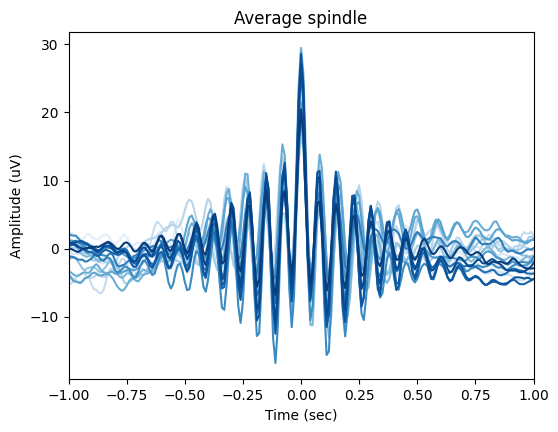

In [21]:
# Because of the large number of channels, we disable the 95%CI and legend
sp.plot_average(ci=None, legend=False, palette="Blues");

In [22]:
sw = yasa.sw_detect(raw, hypno=hyp, include=["N2", "N3"])
sw.summary()

,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,Channel,IdxChannel
0,1747.62,1747.92,1748.59,1748.87,1749.17,1.55,-43.876321,54.247268,98.123589,65.487047,0.645161,2,C3-A2,0
1,1908.98,1909.28,1909.58,1909.80,1910.04,1.06,-58.420493,30.617805,89.038298,194.734976,0.943396,3,C3-A2,0
2,2011.27,2011.57,2011.90,2012.57,2012.83,1.56,-70.472649,27.973122,98.445771,213.553482,0.641026,3,C3-A2,0
3,2020.89,2021.15,2021.40,2021.66,2022.23,1.34,-76.487701,55.478216,131.965917,305.950803,0.746269,3,C3-A2,0
4,2051.89,2052.18,2052.42,2052.64,2052.91,1.02,-79.819462,57.733605,137.553067,332.581093,0.980392,2,C3-A2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12702,25412.76,25413.09,25413.37,25413.48,25413.59,0.83,-69.832216,13.833367,83.665584,249.400773,1.204819,2,T6-A1,18
12703,25525.53,25525.88,25526.78,25527.01,25527.29,1.76,-62.954082,26.520803,89.474885,69.948980,0.568182,2,T6-A1,18
12704,25539.33,25539.66,25539.99,25540.16,25540.37,1.04,-70.802803,20.025750,90.828553,214.553949,0.961538,3,T6-A1,18
12705,25654.23,25654.55,25655.44,25655.99,25656.34,2.11,-68.639844,30.656664,99.296508,77.123420,0.473934,2,T6-A1,18


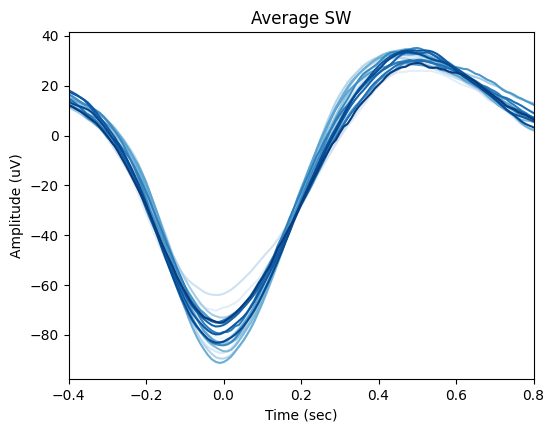

In [23]:
sw.plot_average(ci=None, legend=False, palette="Blues");

/Users/raphael.vallat/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


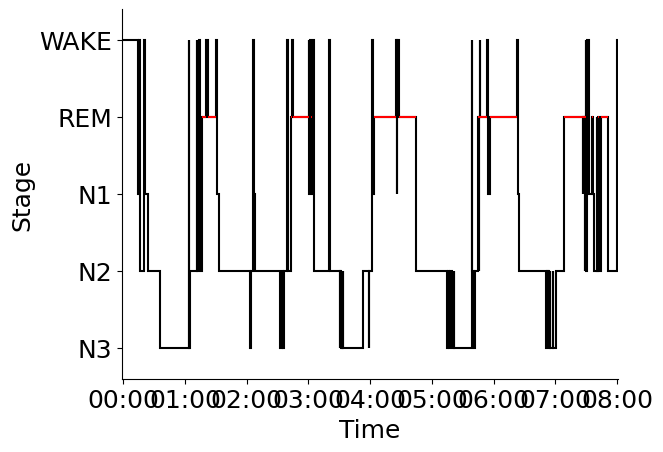

In [24]:
sls = yasa.SleepStaging(raw, eeg_name="C3-A2")
hypno_pred = sls.predict()  # Returns a yasa.Hypnogram
yasa.plot_hypnogram(hypno_pred);  # Plot